In [1]:
# Importamos las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Leemos el 'csv' de "propjectos_forvia"
info_forvia_processed = pd.read_csv("projectos_forvia.csv")

In [3]:
# Con .info() vemos la informacion de la cada columna
info_forvia_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Number                245 non-null    object 
 1   Active                245 non-null    object 
 2   Project Name          245 non-null    object 
 3   Project Type          245 non-null    object 
 4   Geographical scope    245 non-null    object 
 5   Project manager       245 non-null    object 
 6   State                 245 non-null    object 
 7   Percent complete      245 non-null    float64
 8   Project size          245 non-null    object 
 9   Project organization  245 non-null    object 
 10  Planned Go Live date  245 non-null    object 
 11  Project target phase  72 non-null     object 
 12  Actual Go Live date   48 non-null     object 
 13  Actual end date       0 non-null      float64
 14  BG                    245 non-null    object 
 15  Closed                1

In [4]:
# Con .head() nos lanza por completo el csv para ver bien todas la columnas y filas
info_forvia_processed.head()

,Number,Active,Project Name,Project Type,Geographical scope,Project manager,State,Percent complete,Project size,Project organization,...,Closed,Domain,Domain Path,Last WAR,Project Health,Project type,Recurrent activity,Planned start date,Actual start date,On-hold
0,PRJ0075198,VERDADERO,TCO - FIS - ABRERA - VW210 IP,Shopfloor JIT/TCO,ABRERA FIS,BENAVENT Pablo,Work in progress,26.47,SMALL,GIT/IT EMEA/MES & Digital Shopfloor projects,...,NaN,global,/,PRJSTAT0075304,Green,Regular,FALSO,1/2/2025 17:01,NaN,FALSO
1,PRJ0073962,VERDADERO,TCO - FCM - ALLENJOIE FHS - GEN2 New automated...,Shopfloor JIT/TCO,ALLENJOIE FCM,MAUVAIS Julien,Work in progress,52.17,LARGE,GIT/IT EMEA/MES & Digital Shopfloor projects,...,NaN,global,/,PRJSTAT0075248,Yellow,Regular,FALSO,18/01/2024 08:00:00,18/01/2024 08:00:00,VERDADERO
2,PRJ0074556,VERDADERO,TCO - FCM - ALLENJOIE FHS - Tank XL,Shopfloor JIT/TCO,ALLENJOIE FHS,THIERY Jean-Francois,Work in progress,95.85,MEDIUM,GIT/IT EMEA/MES & Digital Shopfloor projects,...,NaN,global,/,PRJSTAT0075265,Yellow,Regular,FALSO,12/8/2024 8:00,12/8/2024 8:00,FALSO
3,PRJ0075087,VERDADERO,TCO - FCM - ALLENJOIE FHS - STELLANTIS - XL694...,Shopfloor JIT/TCO,ALLENJOIE FHS,MAUVAIS Julien,Work in progress,20.90,SMALL,GIT/IT EMEA/MES & Digital Shopfloor projects,...,NaN,global,/,PRJSTAT0075325,Green,Regular,FALSO,8/1/2025 8:00,15/01/2025 09:52:03,VERDADERO
4,PRJ0075456,VERDADERO,TCO – FCM - ALMUSSAFES - FORD - C482 Welding l...,Shopfloor JIT/TCO,ALMUSSAFES FCM,BENAVENT Pablo,Work in progress,24.30,MEDIUM,GIT/IT EMEA/MES & Digital Shopfloor projects,...,NaN,global,/,PRJSTAT0075307,Green,Regular,FALSO,12/5/2025 8:00,12/5/2025 8:00,FALSO


### Con isnull y sum vemos todos los datos nulos que hay dentro de cada columna

In [5]:
info_forvia_processed.isnull().sum()

Number                    1
Active                    1
Project Name              1
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          1
Project size              1
Project organization      1
Planned Go Live date      1
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        1
Closed                  245
Domain                    1
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

### Sacamos una grafica de todos los outliers que hay dentro del Data Frame

In [6]:
numeric_cols = info_forvia_processed.select_dtypes(include=np.number).columns

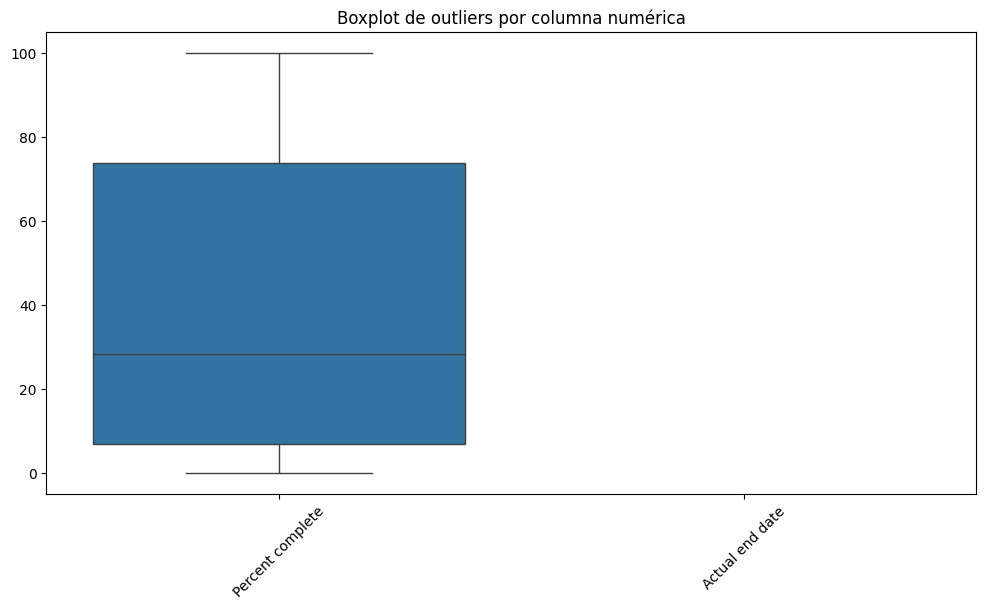

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=info_forvia_processed[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot de outliers por columna numérica")
plt.show()

## Empezamos a remover todos los valores nulos, o sustitydendolos

In [8]:
info_forvia_processed[["Number", "Active", "Project Name"]] = info_forvia_processed[["Number", "Active", "Project Name"]].fillna("NO DEFINE")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              1
Geographical scope        1
Project manager           1
State                     1
Percent complete          1
Project size              1
Project organization      1
Planned Go Live date      1
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        1
Closed                  245
Domain                    1
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

In [9]:
info_forvia_processed[["Project Type", "Geographical scope", "Project manager", "State"]] = info_forvia_processed[["Project Type", "Geographical scope", "Project manager", "State"]].fillna("NO DEFINE")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              0
Geographical scope        0
Project manager           0
State                     0
Percent complete          1
Project size              1
Project organization      1
Planned Go Live date      1
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        1
Closed                  245
Domain                    1
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

### En este caso en la columna de "Percent complete" al ser porcentajes, damomos como valor 0, ya que en si no hay una forma de sacarles por asi decirlo una "media", mas que nada porque habria un desfase de los valores

In [10]:
info_forvia_processed[["Percent complete"]] = info_forvia_processed[["Percent complete"]].fillna("0")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              0
Geographical scope        0
Project manager           0
State                     0
Percent complete          0
Project size              1
Project organization      1
Planned Go Live date      1
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        1
Closed                  245
Domain                    1
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

In [11]:
info_forvia_processed[["Project size", "Project organization", "Planned Go Live date"]] = info_forvia_processed[["Project size", "Project organization", "Planned Go Live date"]].fillna("NO DEFINE")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              0
Geographical scope        0
Project manager           0
State                     0
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        1
Closed                  245
Domain                    1
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

### En esta parte de la columna "Domain" solo habia un valor nulo, y en toda la columna estaba la leyende de "Global", por lo que se decidio solo agregarle otro mas.

In [12]:
info_forvia_processed[["Domain"]] = info_forvia_processed[["Domain"]].fillna("Global")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              0
Geographical scope        0
Project manager           0
State                     0
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        1
Closed                  245
Domain                    0
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

In [13]:
info_forvia_processed[["BG"]] = info_forvia_processed[["BG"]].fillna("NO DEFINE")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              0
Geographical scope        0
Project manager           0
State                     0
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        0
Closed                  245
Domain                    0
Domain Path               1
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

### En esta parte lo mismo que en "Domain" ya que solo habia una celda vacia y con los mismos datos

In [14]:
info_forvia_processed[["Domain Path"]] = info_forvia_processed[["Domain Path"]].fillna("/")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              0
Geographical scope        0
Project manager           0
State                     0
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        0
Closed                  245
Domain                    0
Domain Path               0
Last WAR                 14
Project Health           14
Project type              1
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

### De la misma manera en esta parte

In [15]:
info_forvia_processed[["Project type"]] = info_forvia_processed[["Project type"]].fillna("REGULAR")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              0
Geographical scope        0
Project manager           0
State                     0
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        0
Closed                  245
Domain                    0
Domain Path               0
Last WAR                 14
Project Health           14
Project type              0
Recurrent activity        1
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

### De igual manera en esta parte

In [16]:
info_forvia_processed[["Recurrent activity"]] = info_forvia_processed[["Recurrent activity"]].fillna("FALSO")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              0
Geographical scope        0
Project manager           0
State                     0
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        0
Closed                  245
Domain                    0
Domain Path               0
Last WAR                 14
Project Health           14
Project type              0
Recurrent activity        0
Planned start date        0
Actual start date        19
On-hold                   1
dtype: int64

In [17]:
info_forvia_processed[["On-hold"]] = info_forvia_processed[["On-hold"]].fillna("NO DEFINE")
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              0
Geographical scope        0
Project manager           0
State                     0
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
Actual end date         246
BG                        0
Closed                  245
Domain                    0
Domain Path               0
Last WAR                 14
Project Health           14
Project type              0
Recurrent activity        0
Planned start date        0
Actual start date        19
On-hold                   0
dtype: int64

## En esta parte borramos dos columnas, la primera "Actual end date" ya que esta vacia, y en "Closed" solo habia un dato

In [18]:
info_forvia_processed=info_forvia_processed.drop(['Actual end date', 'Closed'],axis=1)
info_forvia_processed.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              0
Geographical scope        0
Project manager           0
State                     0
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    174
Actual Go Live date     198
BG                        0
Domain                    0
Domain Path               0
Last WAR                 14
Project Health           14
Project type              0
Recurrent activity        0
Planned start date        0
Actual start date        19
On-hold                   0
dtype: int64

In [19]:
info_forvia_processed[["Project target phase", "Actual Go Live date", "Last WAR", "Project Health", "Actual start date"]] = info_forvia_processed[["Project target phase", "Actual Go Live date", "Last WAR", "Project Health", "Actual start date"]].fillna("NO DEFINE")
info_forvia_processed.isnull().sum()

Number                  0
Active                  0
Project Name            0
Project Type            0
Geographical scope      0
Project manager         0
State                   0
Percent complete        0
Project size            0
Project organization    0
Planned Go Live date    0
Project target phase    0
Actual Go Live date     0
BG                      0
Domain                  0
Domain Path             0
Last WAR                0
Project Health          0
Project type            0
Recurrent activity      0
Planned start date      0
Actual start date       0
On-hold                 0
dtype: int64

## Realizamos un analisis univariado de las variables categoricas, mostrando tablas de frecuencias y graficas de barras para cada una.

Tabla de frecuencias para: Project Type


,count
Project Type,
Shopfloor JIT/TCO,80
FCS roll-outs,75
New software or release,46
Shopfloor LES/NEO,13
Studies / Moves / Solution Selection / Other,8
New Site infrastructure,7
Overall Project Coordination,6
Shopfloor DMC/SPC,5
New infrastructure,3


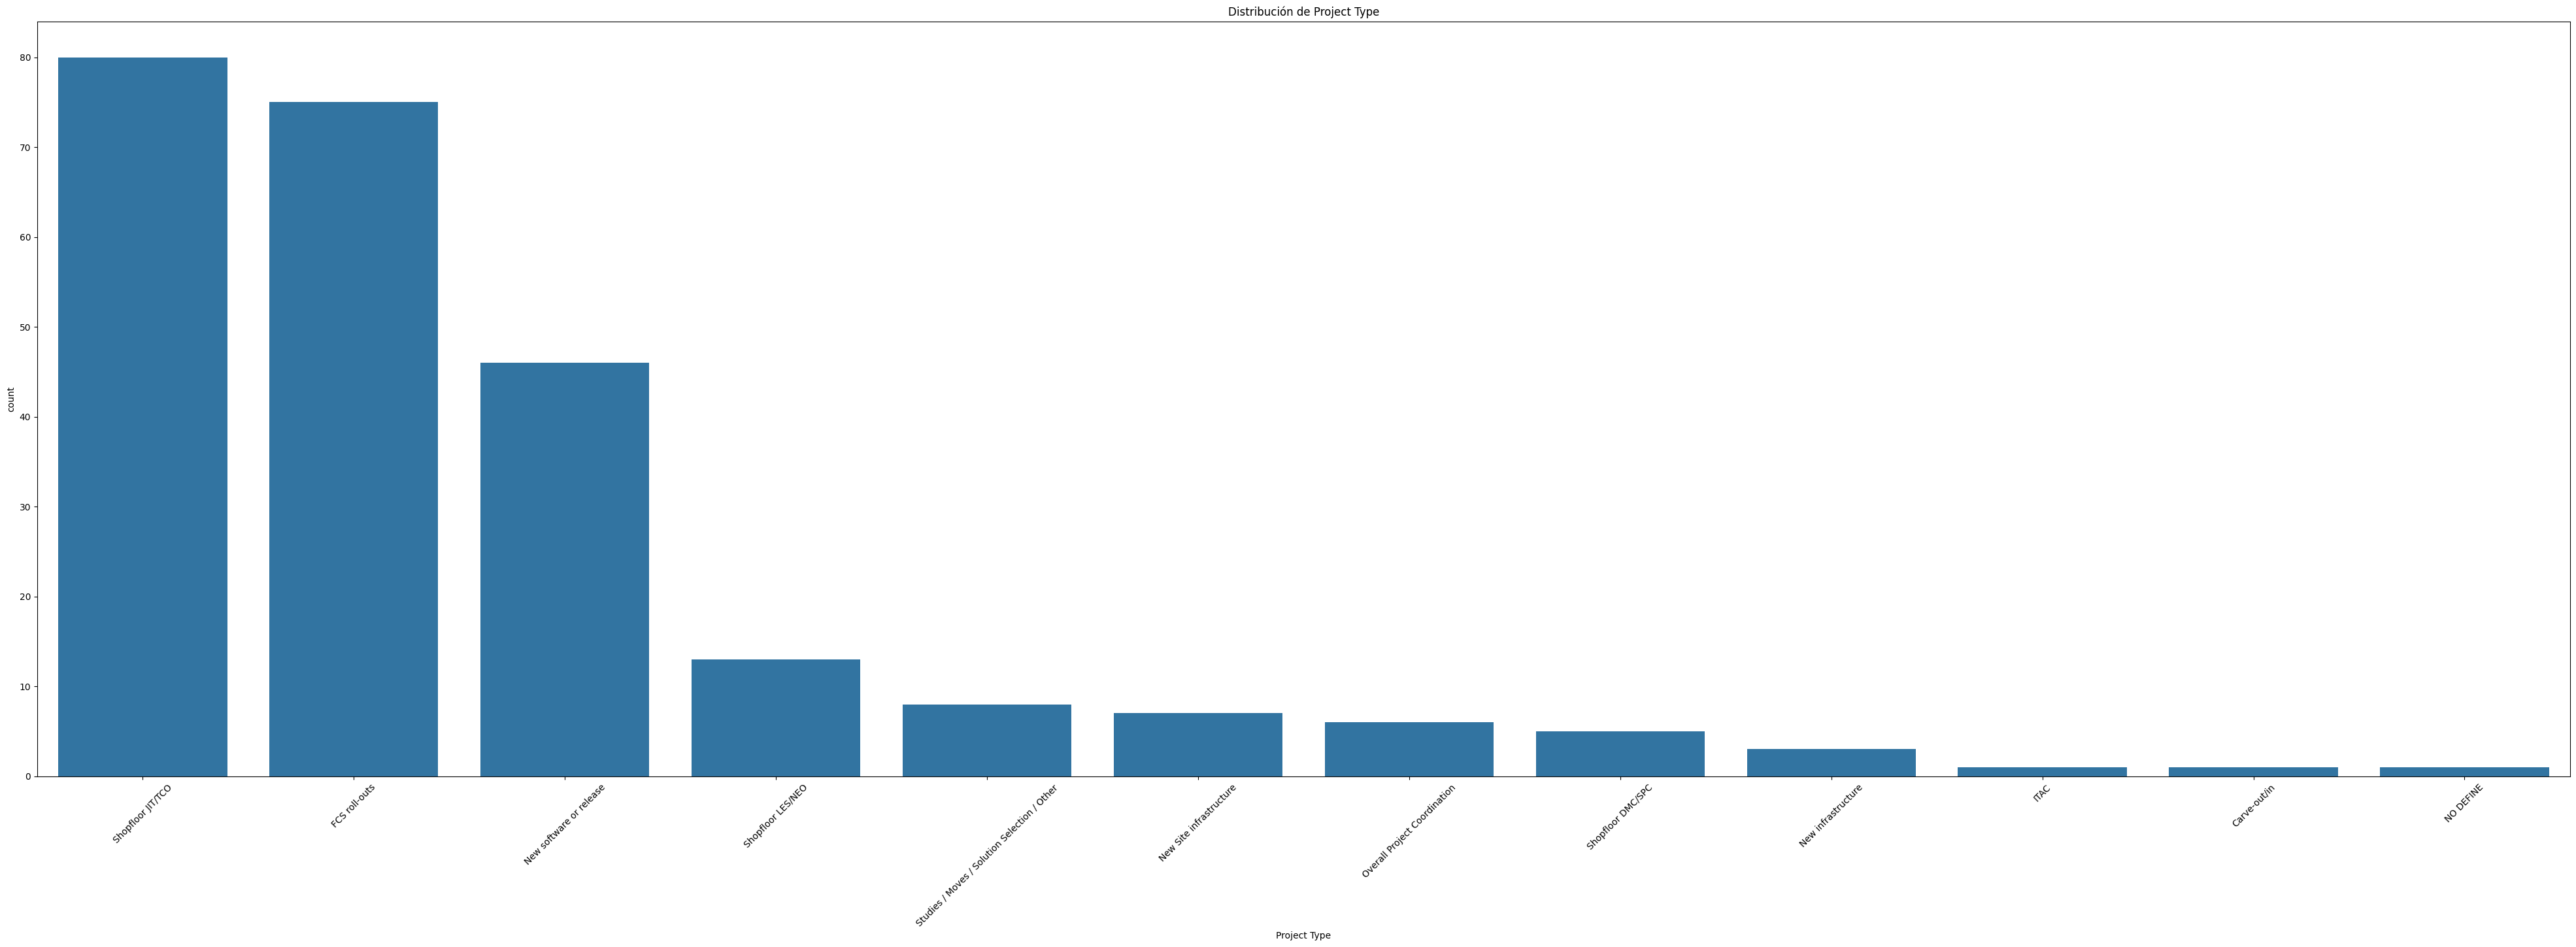

Tabla de frecuencias para: Geographical scope


,count
Geographical scope,
WORLD WIDE,20
BRAZIL,9
PUEBLA HQ,7
BRAGANCA,6
PARIS TECH CENTER,5
...,...
TRNAVA FAS,1
WUHAN FIS,1
WALBRZYCH Pneumatic,1


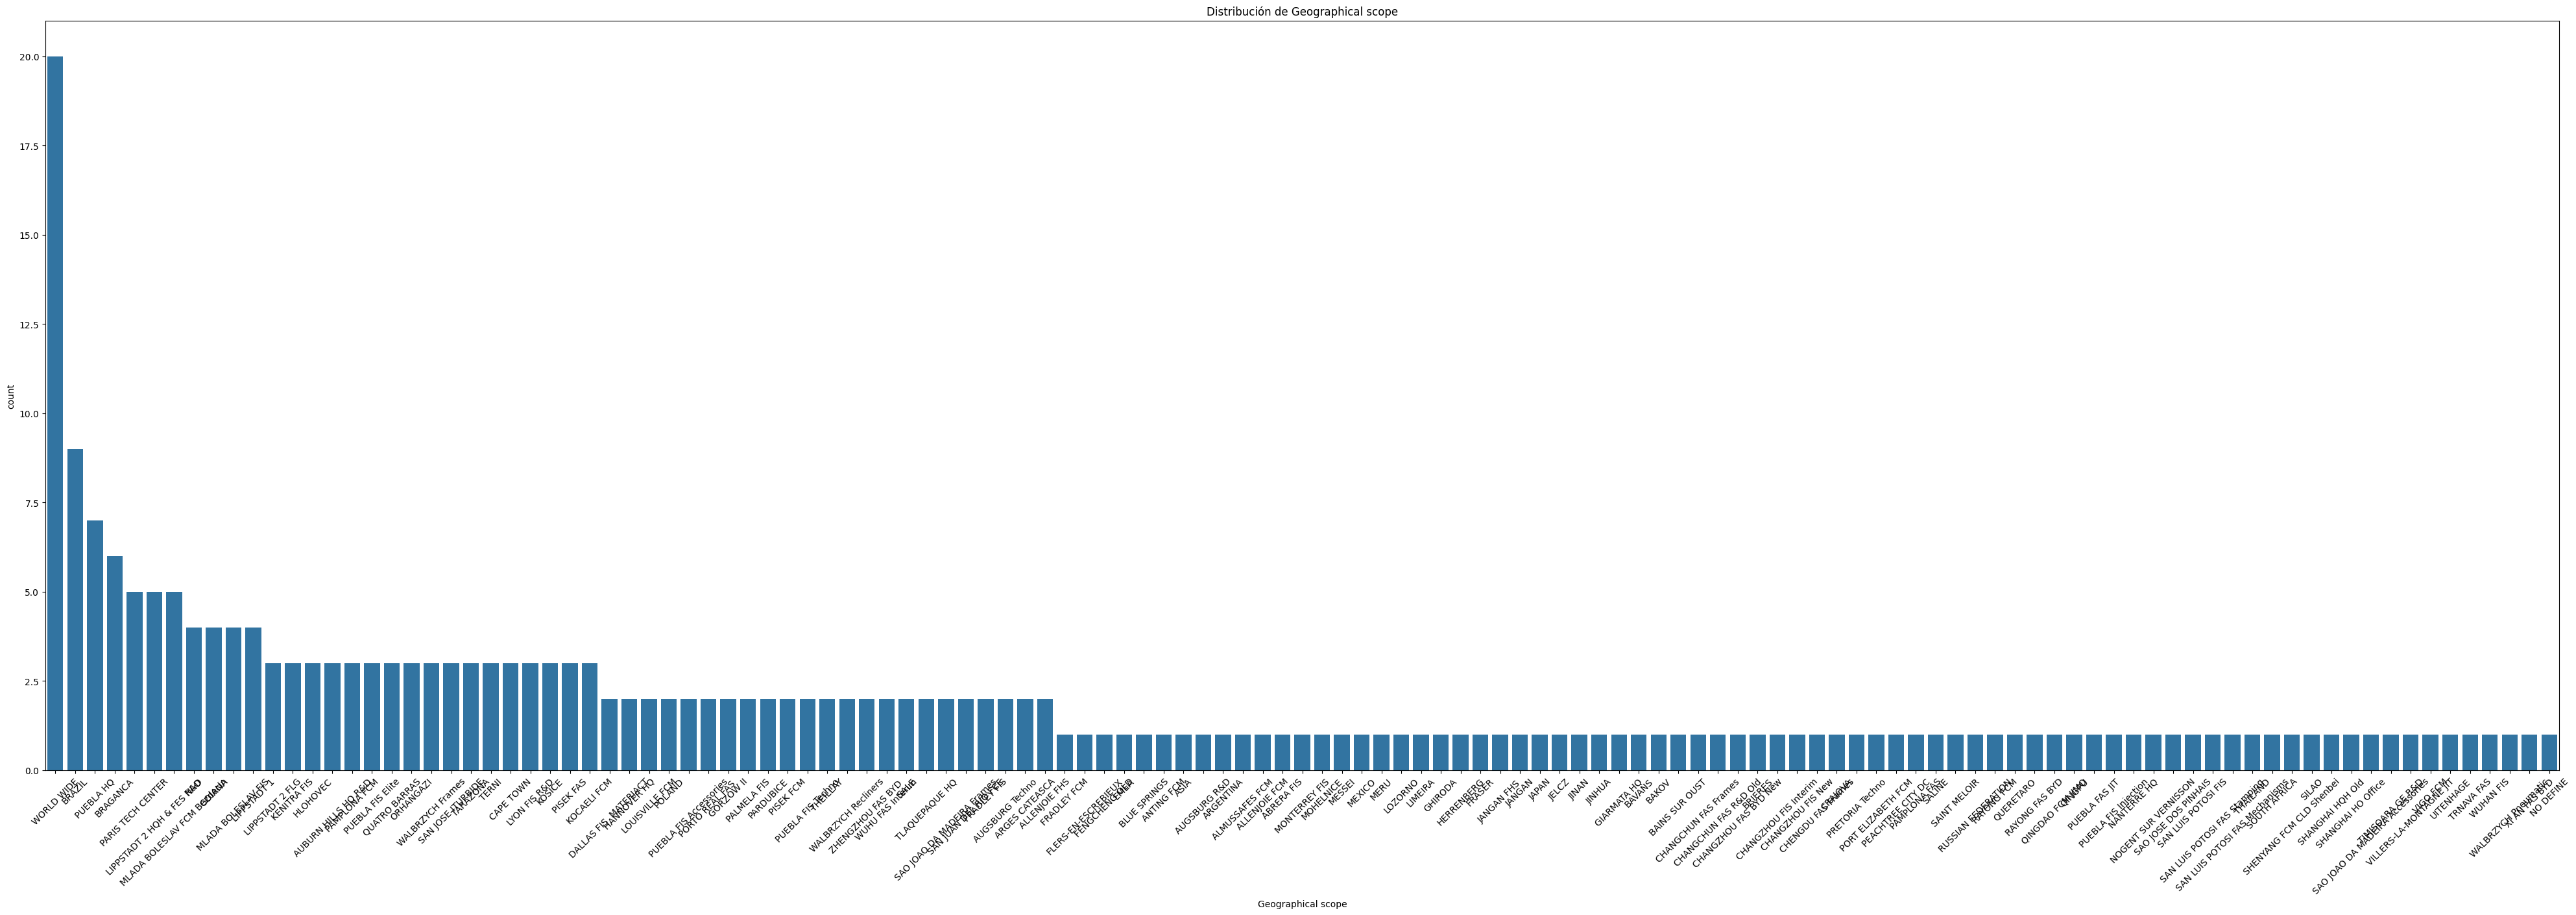

Tabla de frecuencias para: Project manager


,count
Project manager,
SOUZA Alexandre,15
BENAVENT Pablo,12
SVARICEK Dan,9
LOUBET Diana,9
MALTER Karsten,7
...,...
REGNAT Stefan,1
TRAUTMANN Roland,1
CHEN Ken,1


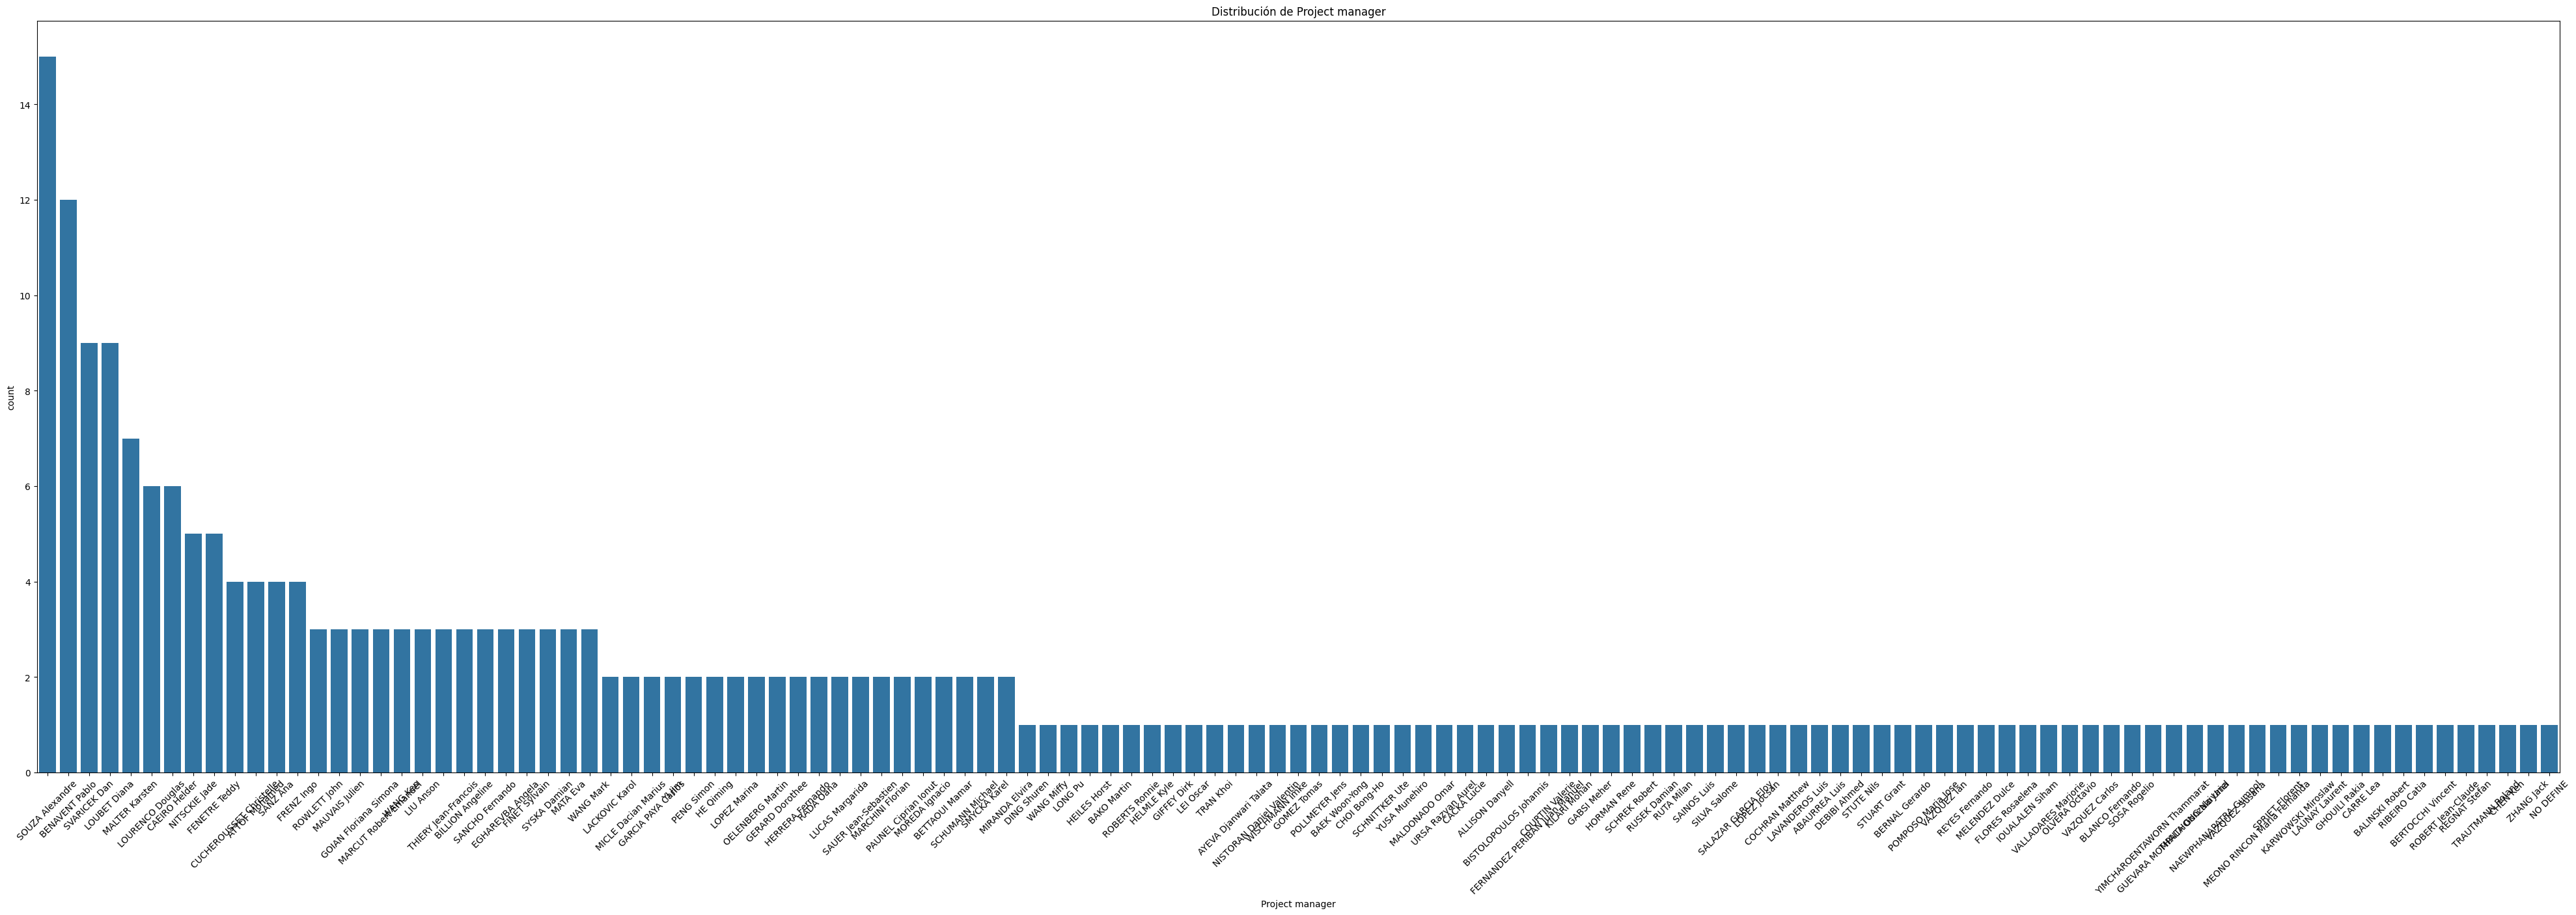

Tabla de frecuencias para: State


,count
State,
Work in progress,232
Pending,12
Open,1
NO DEFINE,1


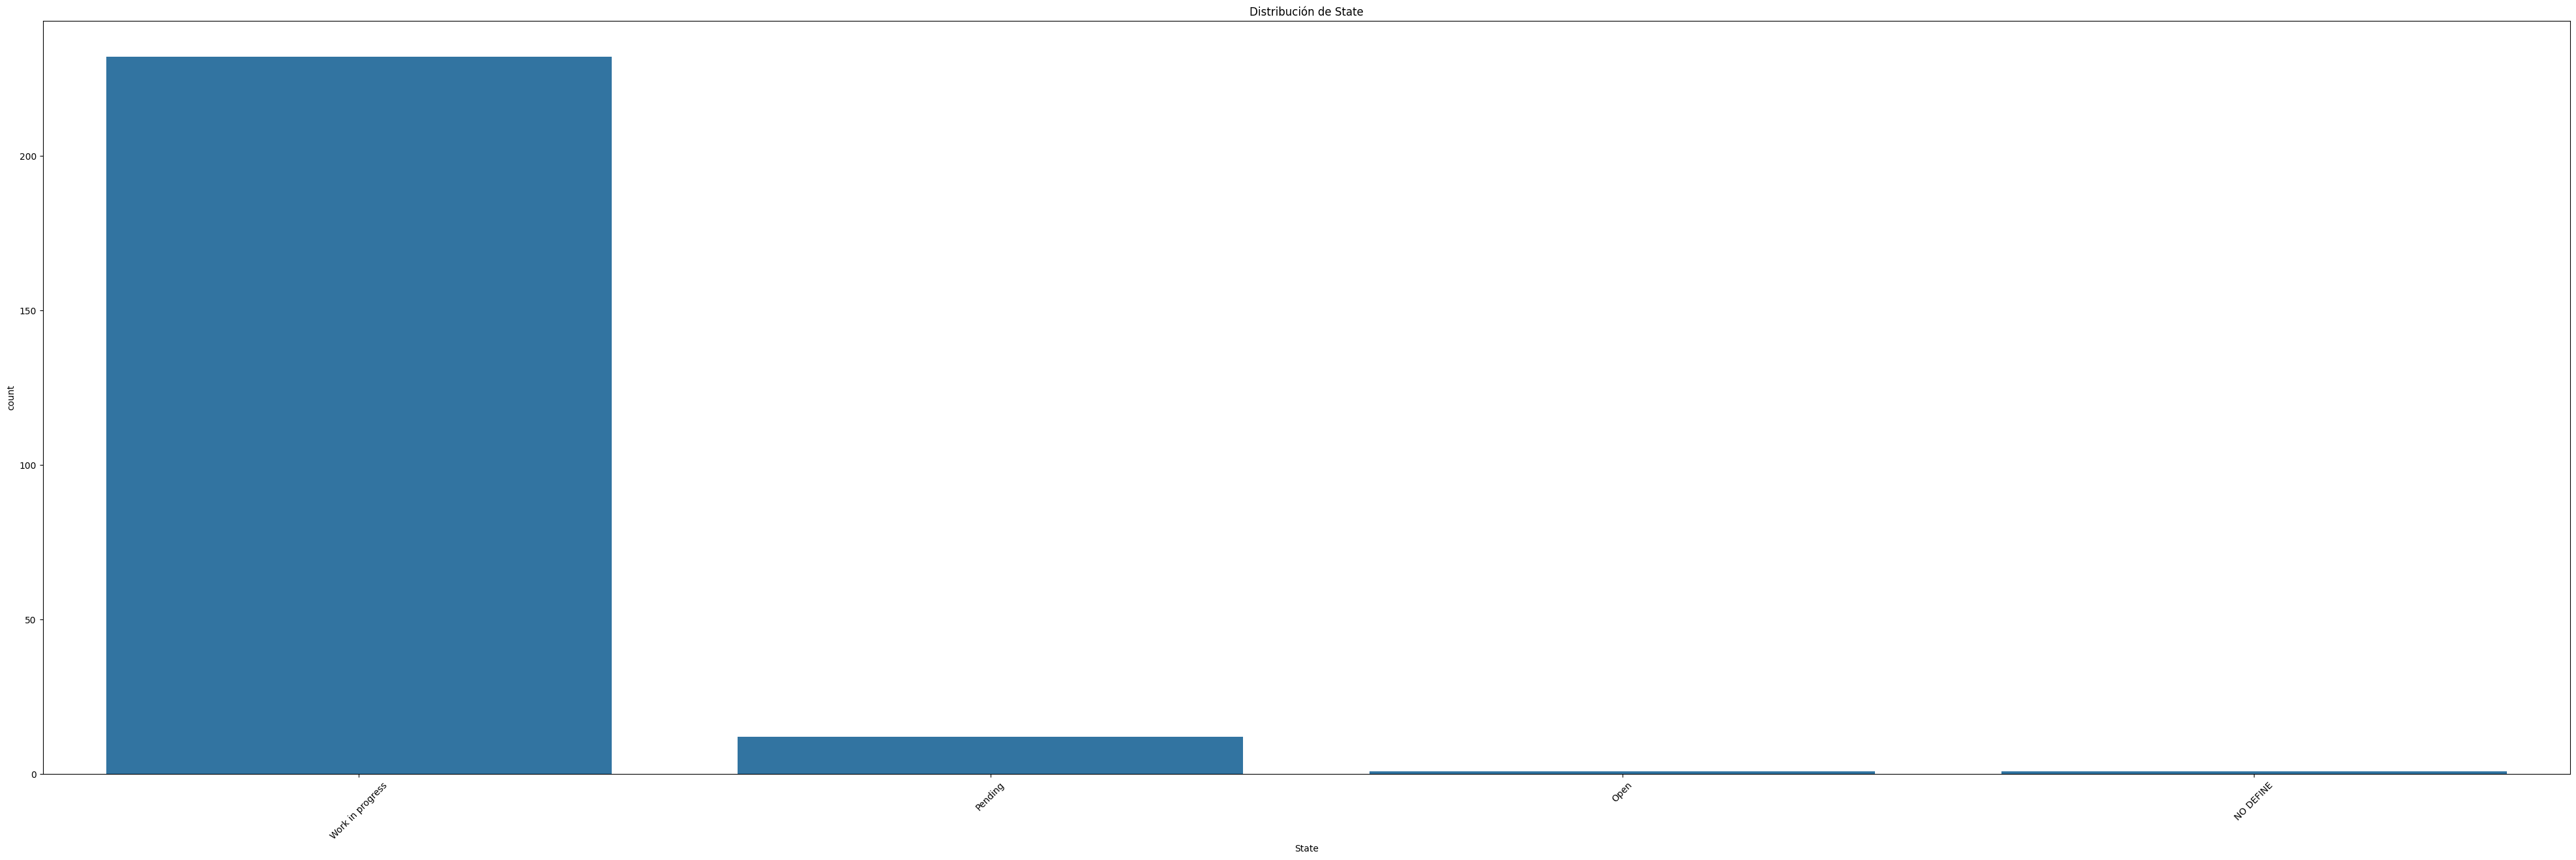

Tabla de frecuencias para: Project size


,count
Project size,
MEDIUM,103
LARGE,81
SMALL,61
NO DEFINE,1


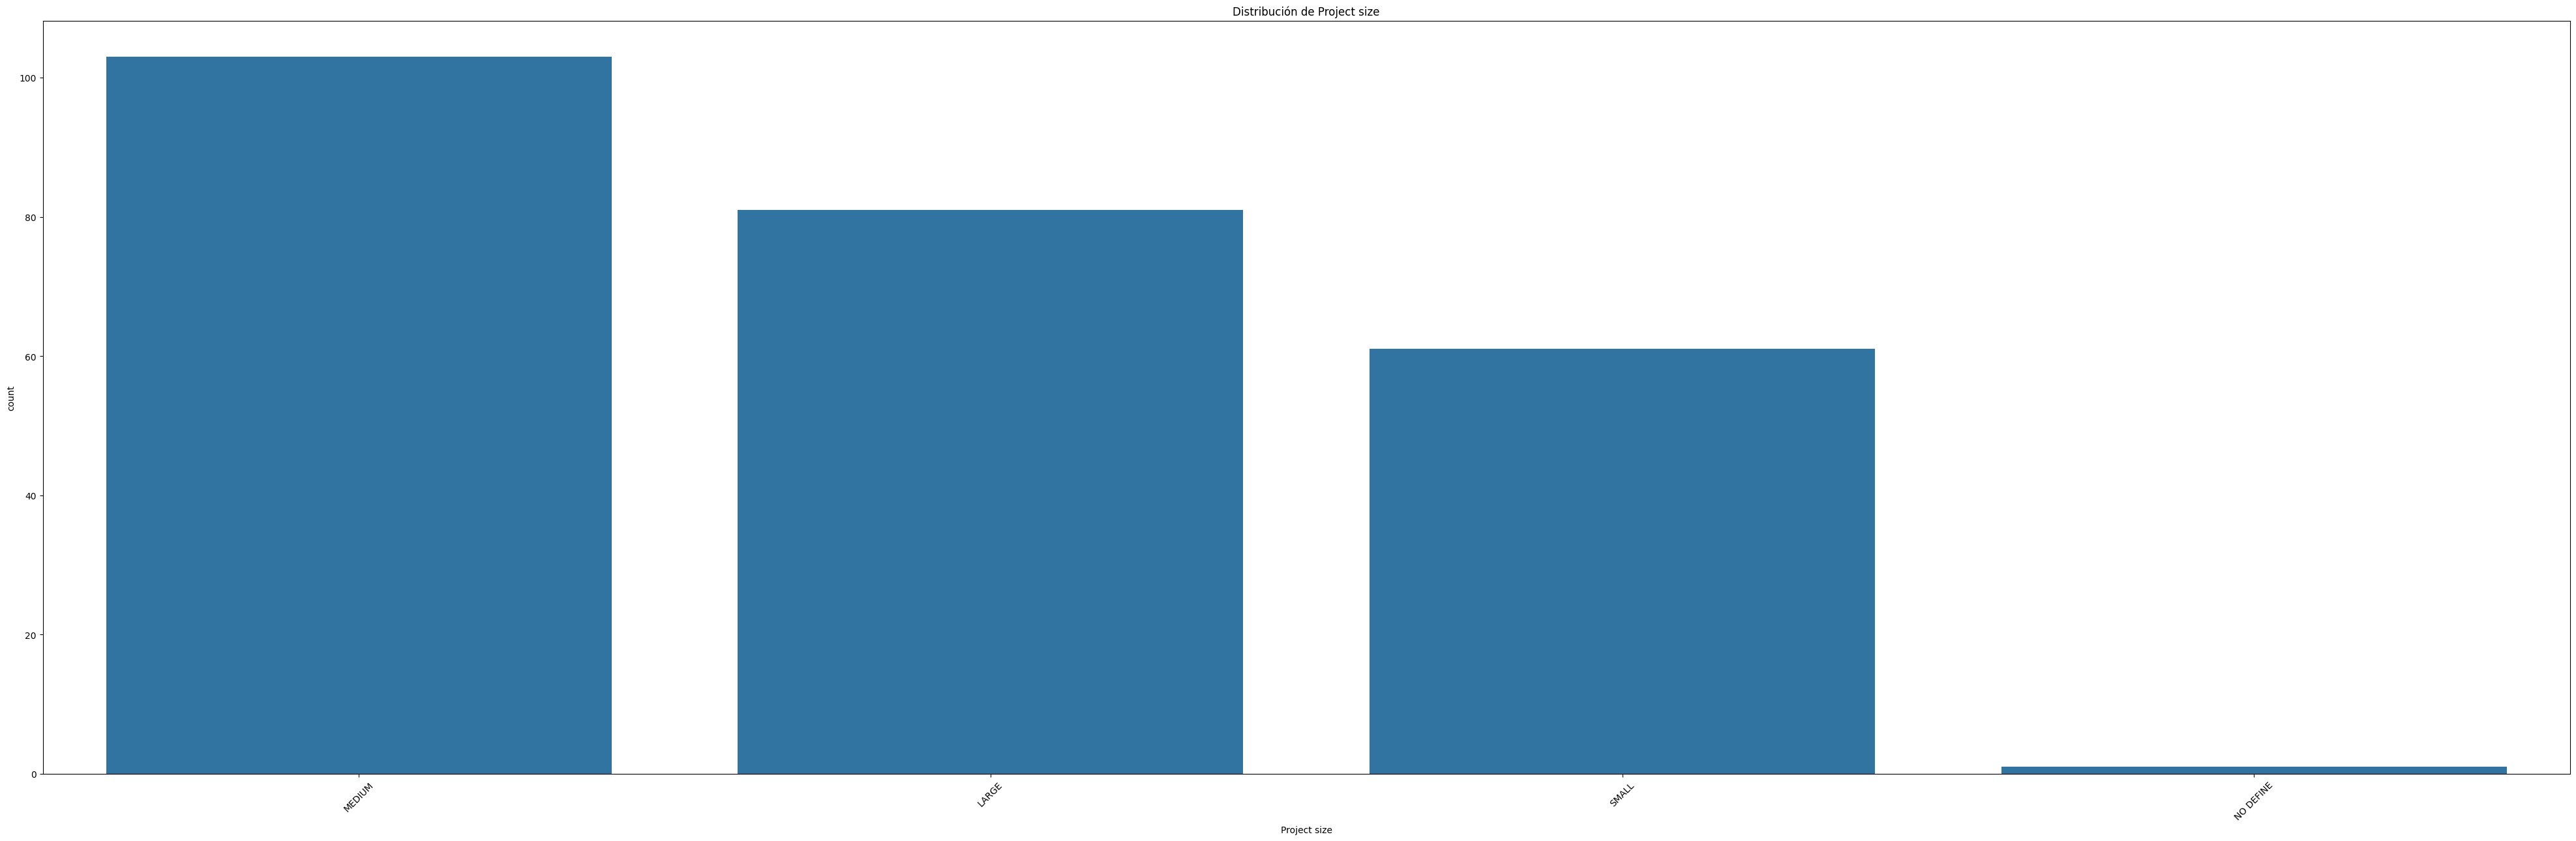

Tabla de frecuencias para: Project organization


,count
Project organization,
GIT/IT EMEA/MES & Digital Shopfloor projects,61
GIT/IT EMEA/Applications rollouts & Level 2 Support,42
GIS/ITOP SAO./IT OP SAO shared/ITOP SAO FCS & BPA.,15
GIS/ITOP ASIA/IT OP Asia Shared/ITOP ASIA MES & Digital Transformation,14
GIT/IT NAO/MES Applications & DT/Mexico MES,13
GIT/Applications,10
GIT/Applications/Engineering / R&D Domain,10
GIT/IT NAO/NAO Applications/FCS,9
GIS/ITOP ASIA/IT OP Asia Shared/ITOP ASIA Infrastructure,8


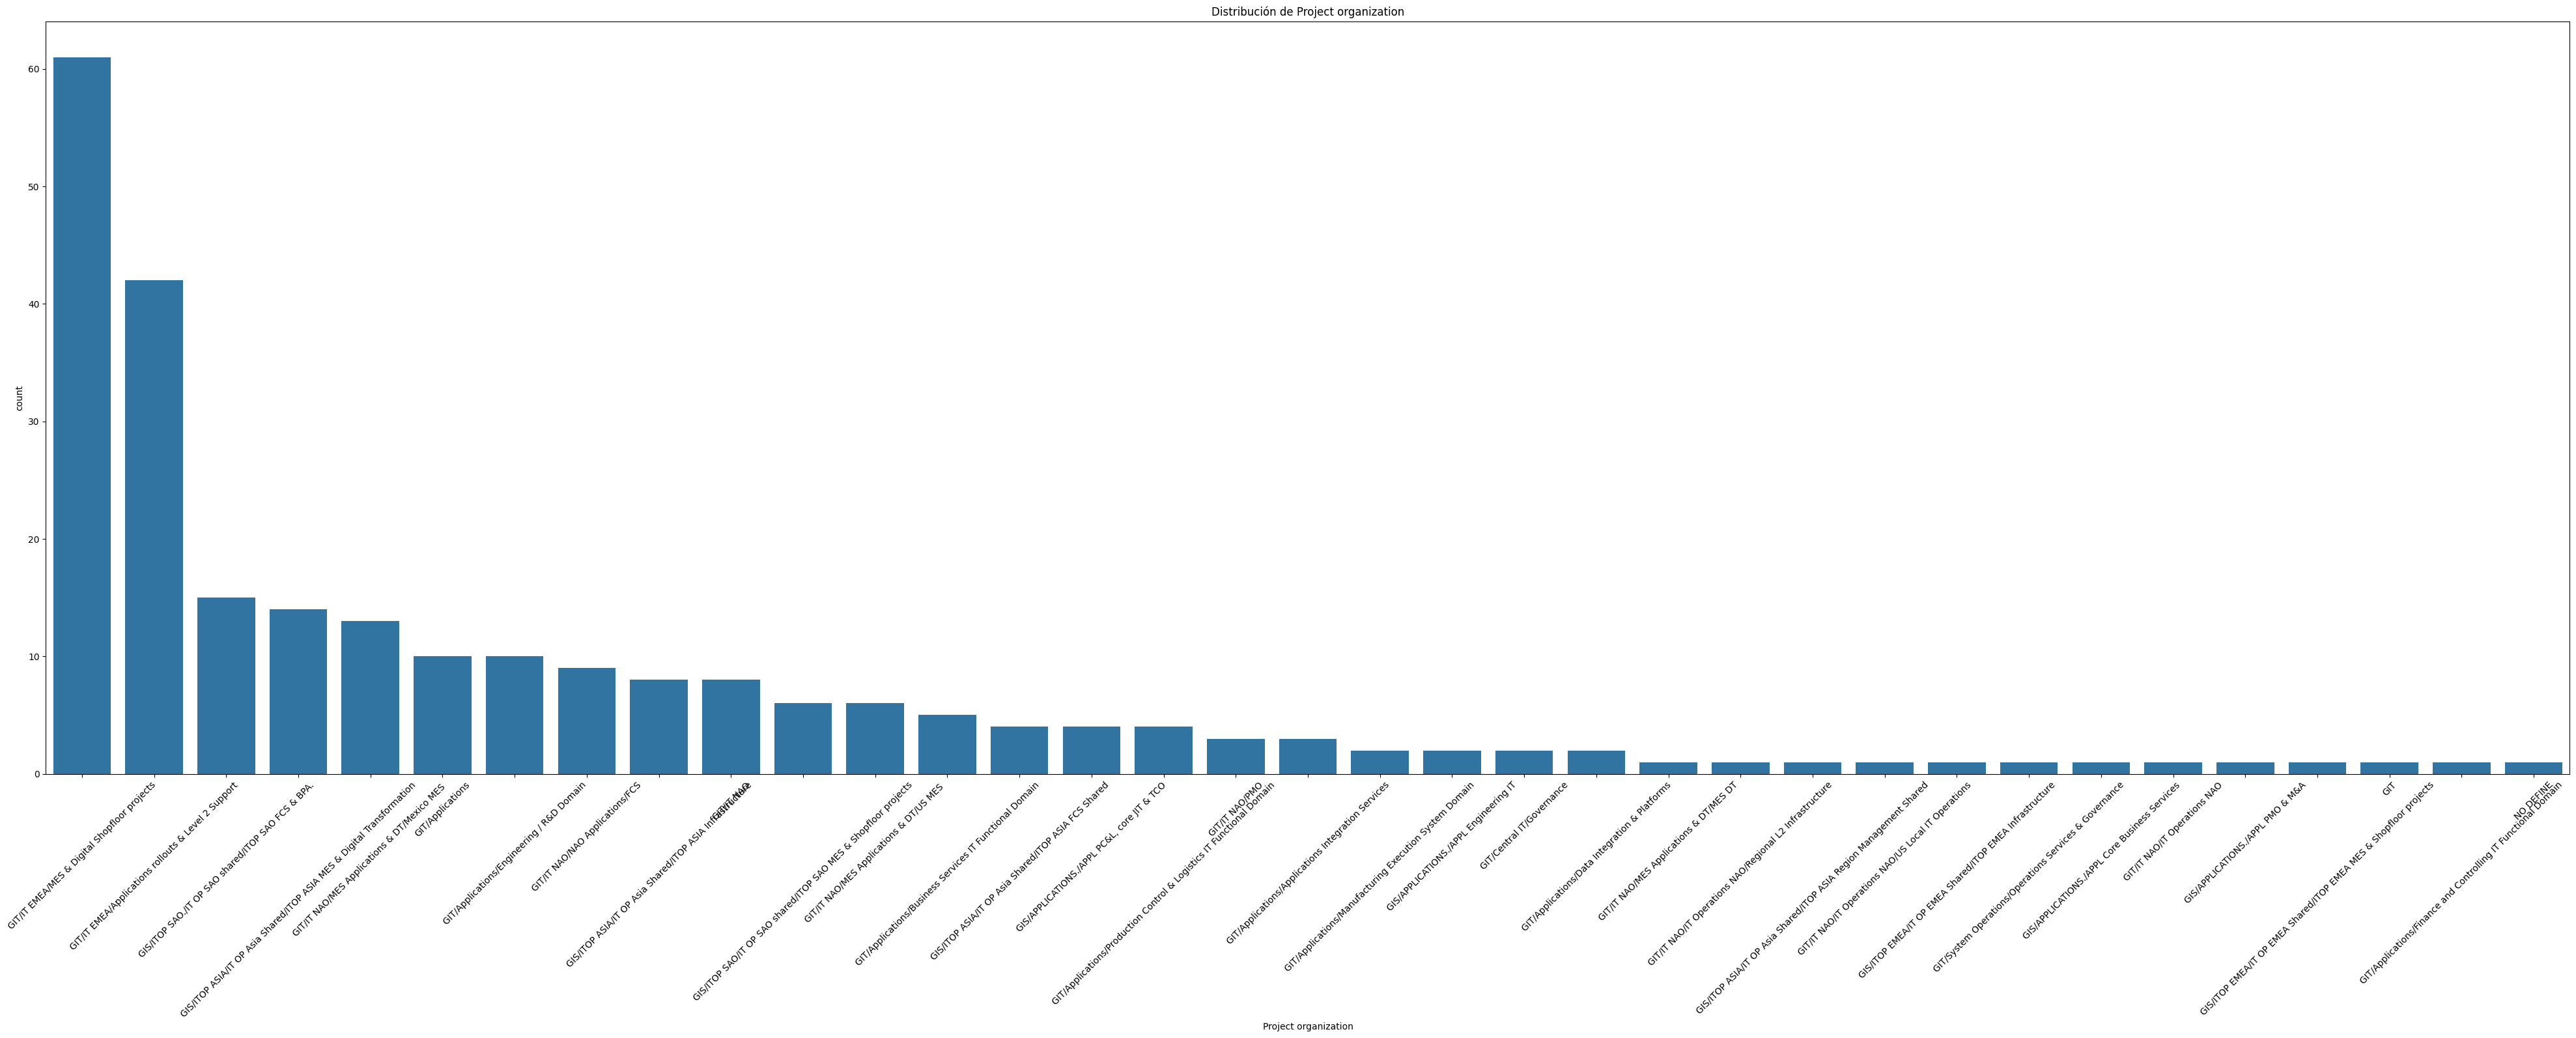

Tabla de frecuencias para: BG


,count
BG,
FIS,69
FCM,57
FAS,45
GROUP,40
FCE,8
FLG,8
FES,6
HQH,6
FLV,5


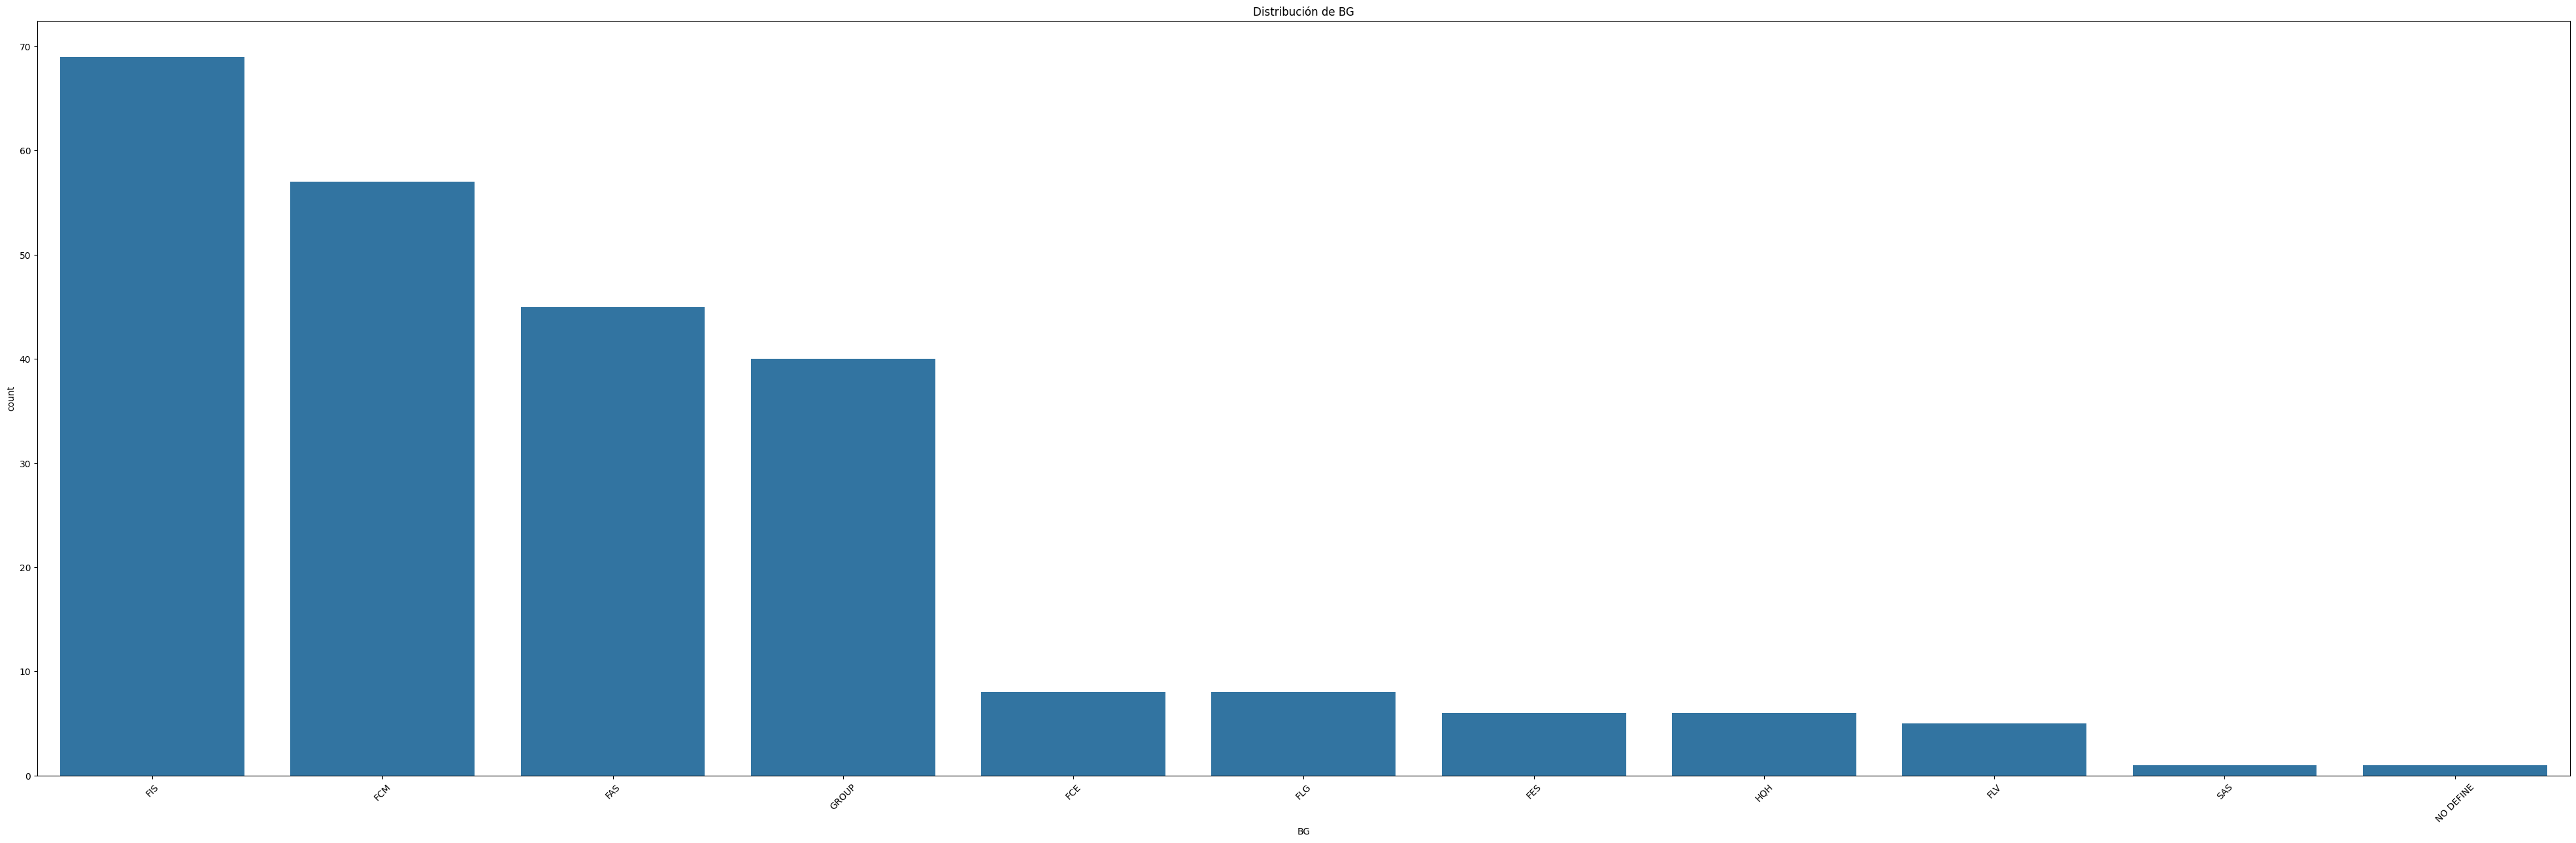

Tabla de frecuencias para: Project Health


,count
Project Health,
Green,183
Yellow,49
NO DEFINE,14


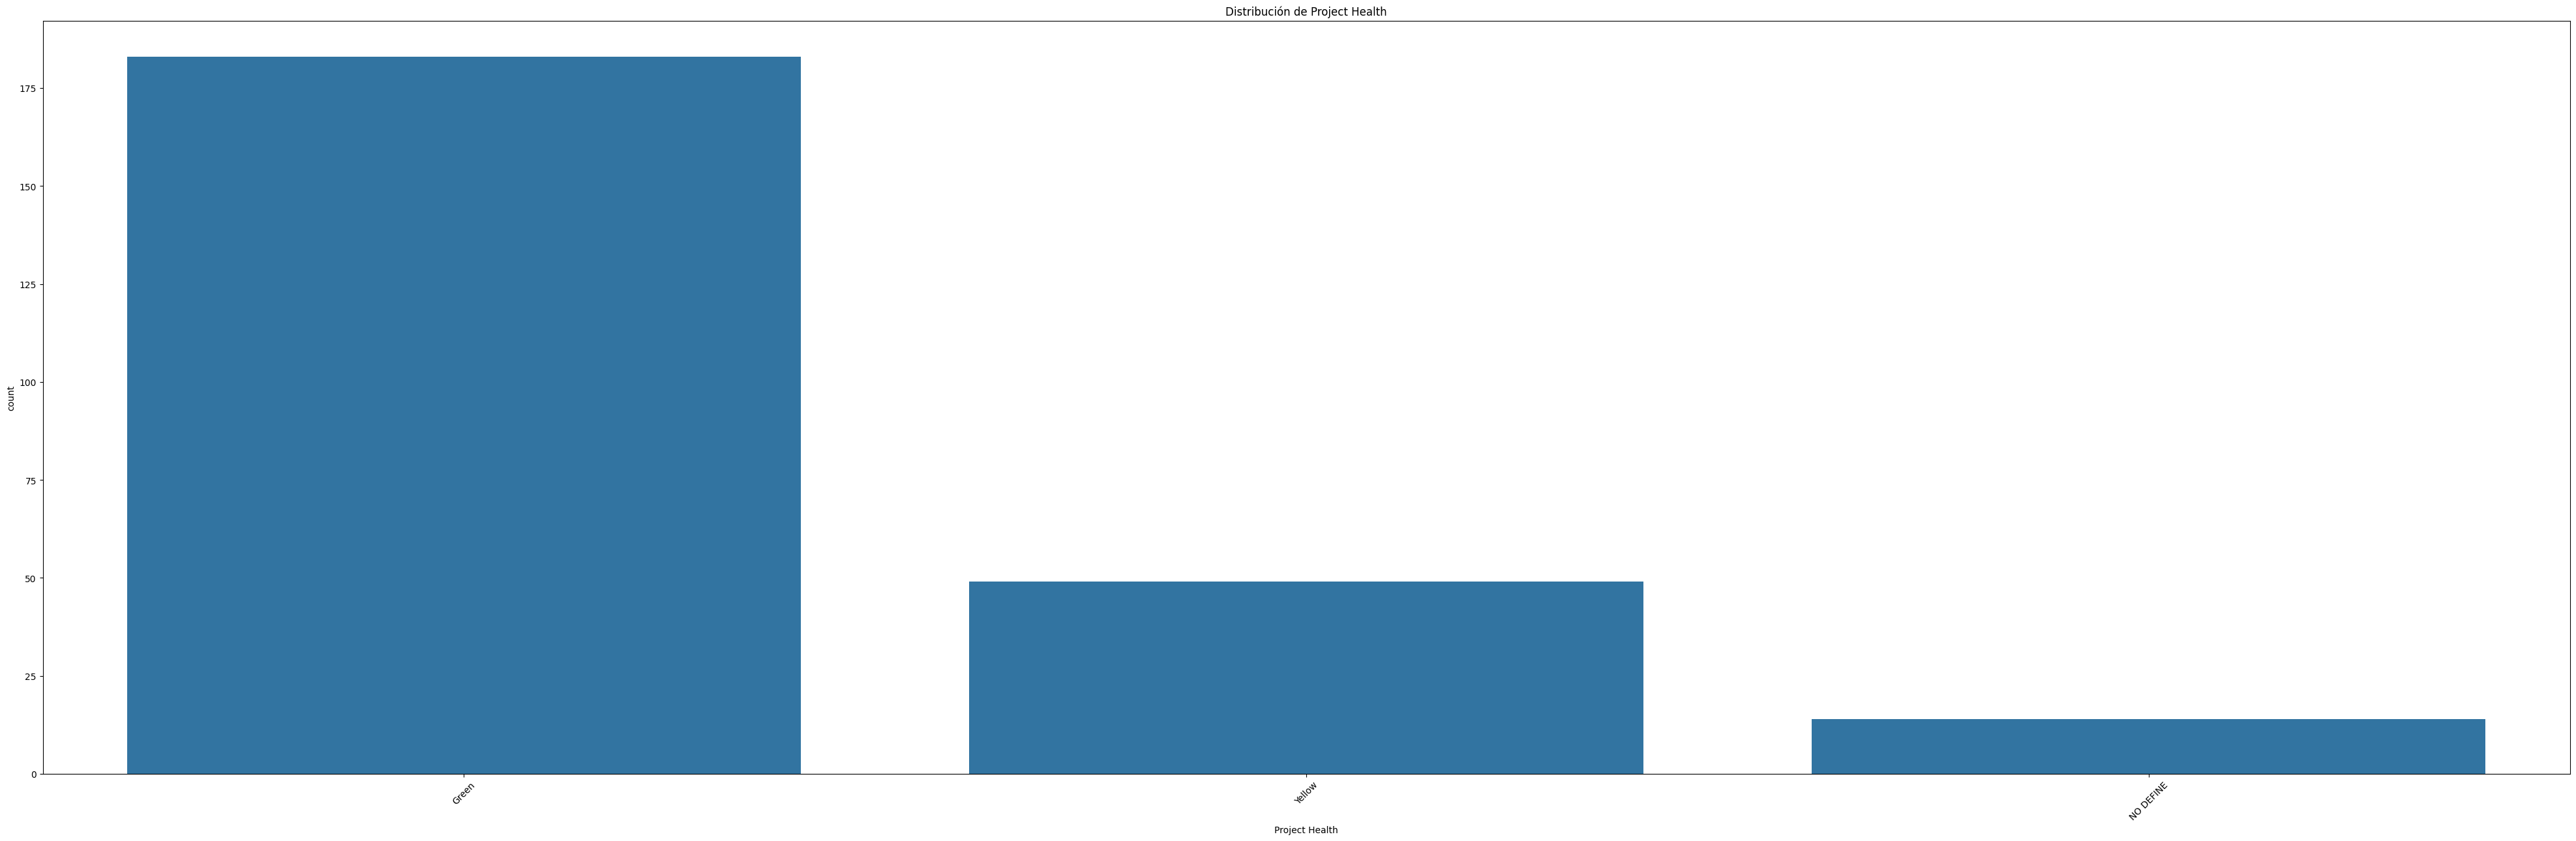

Tabla de frecuencias para: On-hold


,count
On-hold,
FALSO,195
VERDADERO,50
NO DEFINE,1


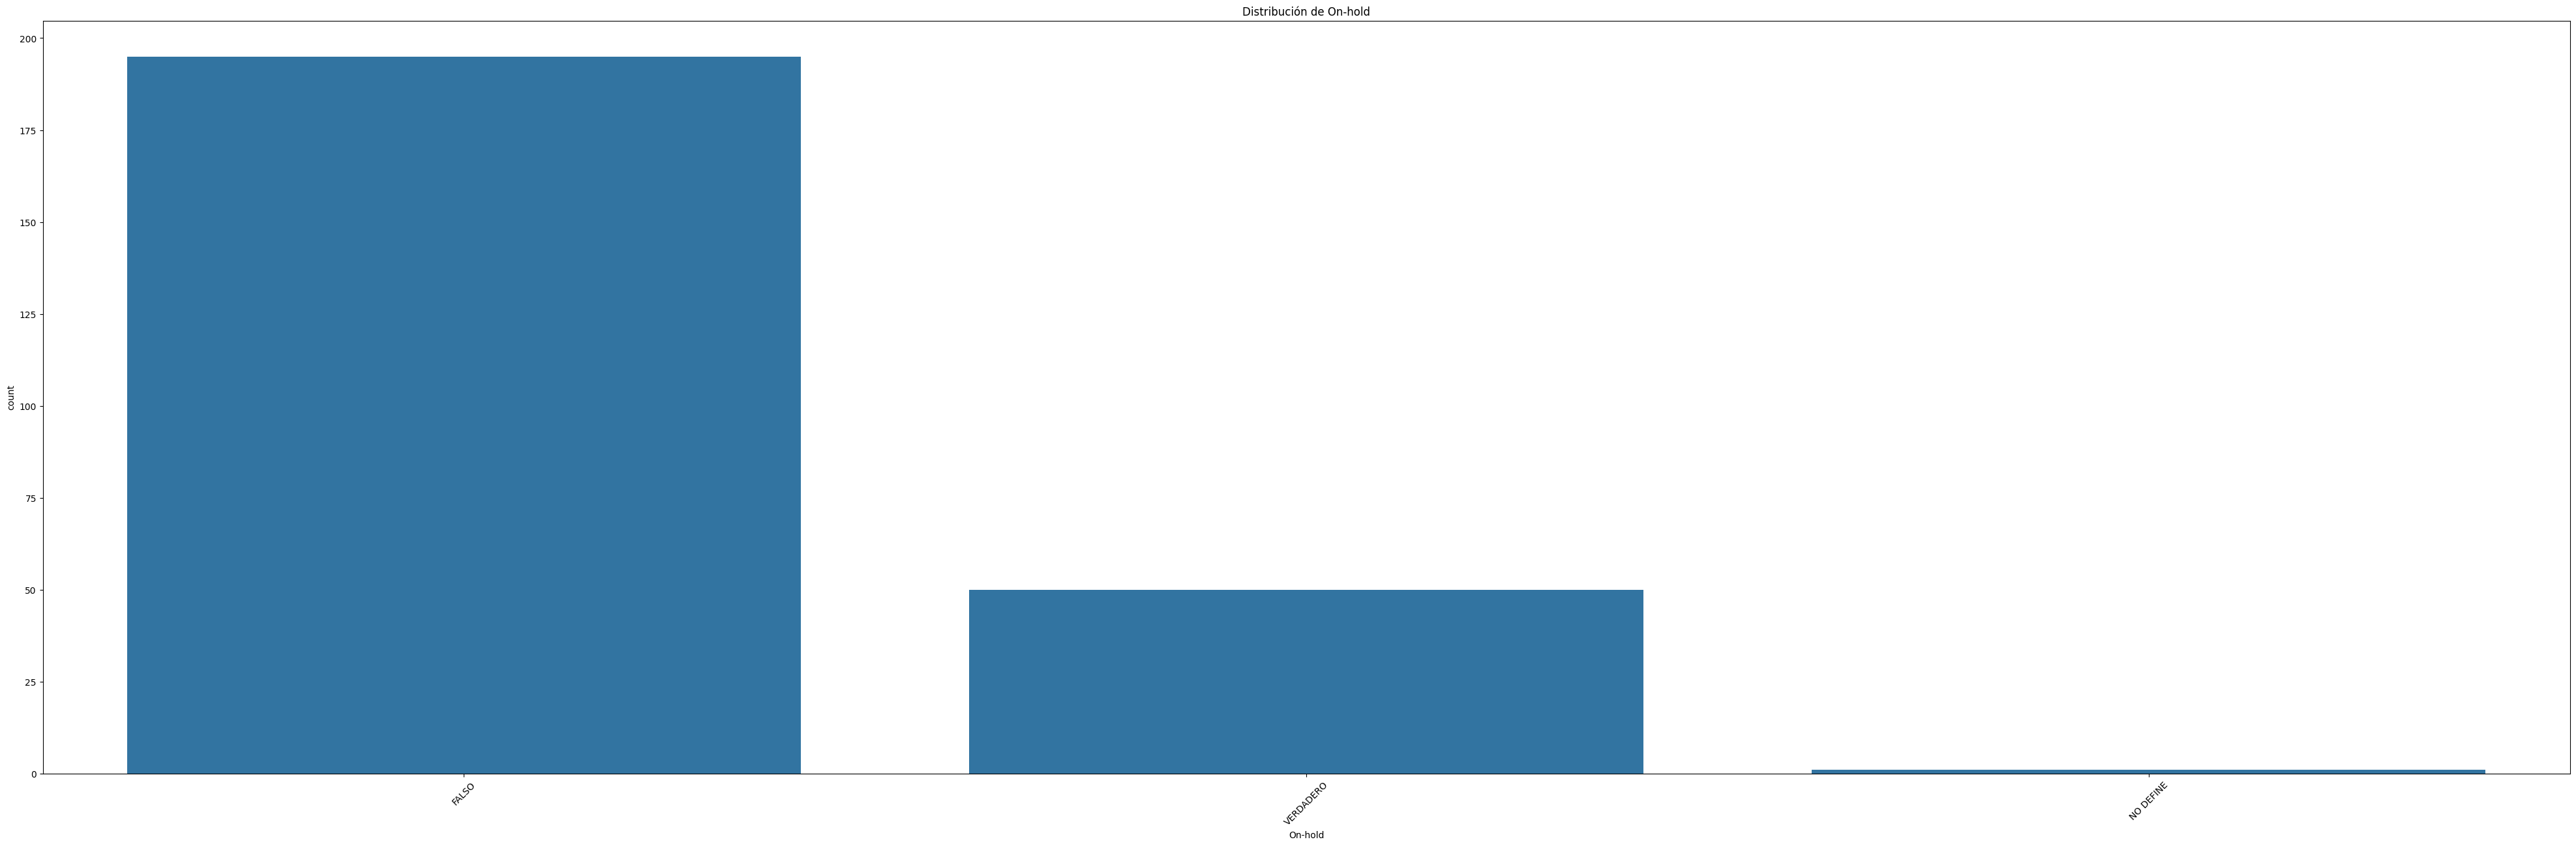

In [20]:
categorical_vars = [
    "Project Type", "Geographical scope", "Project manager", "State",
    "Project size", "Project organization", "BG", "Project Health", "On-hold"
]

for col in categorical_vars:
    print(f"Tabla de frecuencias para: {col}")
    display(info_forvia_processed[col].value_counts().to_frame())
    
    plt.figure(figsize=(50, 15))
    sns.countplot(data=info_forvia_processed, x=col, order=info_forvia_processed[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Distribución de {col}")
    plt.show()

In [22]:
Tabla_freq2 = info_forvia_processed['Geographical scope'].value_counts().reset_index()
pd.options.display.max_rows = None
Tabla_freq2.head(15)

,Geographical scope,count
0,WORLD WIDE,20
1,BRAZIL,9
2,PUEBLA HQ,7
3,BRAGANCA,6
4,PARIS TECH CENTER,5
5,LIPPSTADT 2 HQH & FES R&D,5
6,MLADA BOLESLAV FCM Bezdecin,5
7,NAO,4
8,GOIANA,4
9,MLADA BOLESLAV FIS,4


In [24]:
Filtro3 = Tabla_freq2[Tabla_freq2['count']>3]
Filtro3

,Geographical scope,count
0,WORLD WIDE,20
1,BRAZIL,9
2,PUEBLA HQ,7
3,BRAGANCA,6
4,PARIS TECH CENTER,5
5,LIPPSTADT 2 HQH & FES R&D,5
6,MLADA BOLESLAV FCM Bezdecin,5
7,NAO,4
8,GOIANA,4
9,MLADA BOLESLAV FIS,4


In [25]:
Filtro3_index= Filtro3.set_index('Geographical scope')
Filtro3_index

,count
Geographical scope,
WORLD WIDE,20
BRAZIL,9
PUEBLA HQ,7
BRAGANCA,6
PARIS TECH CENTER,5
LIPPSTADT 2 HQH & FES R&D,5
MLADA BOLESLAV FCM Bezdecin,5
NAO,4
GOIANA,4


Text(0, 0.5, 'Frecuencia')

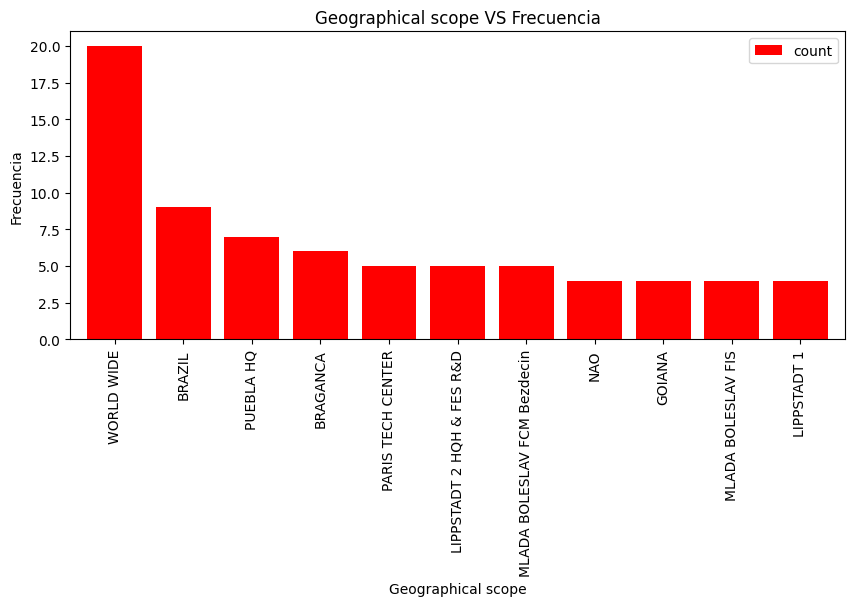

In [27]:
Filtro3_index.plot(kind='bar', width=0.8, figsize=(10,4), color="red")
plt.title('Geographical scope VS Frecuencia')
plt.xlabel('Geographical scope')
plt.ylabel('Frecuencia')

In [ ]:
Tabla_freq2 = info_forvia_processed['Project manager'].value_counts().reset_index()
pd.options.display.max_rows = None
Tabla_freq2.head(15)

,Project manager,count
0,SOUZA Alexandre,15
1,BENAVENT Pablo,12
2,SVARICEK Dan,9
3,LOUBET Diana,9
4,MALTER Karsten,7
5,LOURENCO Douglas,6
6,CAEIRO Helder,6
7,NITSCKIE Jade,5
8,FENETRE Teddy,5
9,CUCHEROUSSET Christelle,4


In [29]:
Filtro3 = Tabla_freq2[Tabla_freq2['count']>3]
Filtro3

,Project manager,count
0,SOUZA Alexandre,15
1,BENAVENT Pablo,12
2,SVARICEK Dan,9
3,LOUBET Diana,9
4,MALTER Karsten,7
5,LOURENCO Douglas,6
6,CAEIRO Helder,6
7,NITSCKIE Jade,5
8,FENETRE Teddy,5
9,CUCHEROUSSET Christelle,4


In [30]:
Filtro3_index= Filtro3.set_index('Project manager')
Filtro3_index

,count
Project manager,
SOUZA Alexandre,15
BENAVENT Pablo,12
SVARICEK Dan,9
LOUBET Diana,9
MALTER Karsten,7
LOURENCO Douglas,6
CAEIRO Helder,6
NITSCKIE Jade,5
FENETRE Teddy,5


Text(0, 0.5, 'Frecuencia')

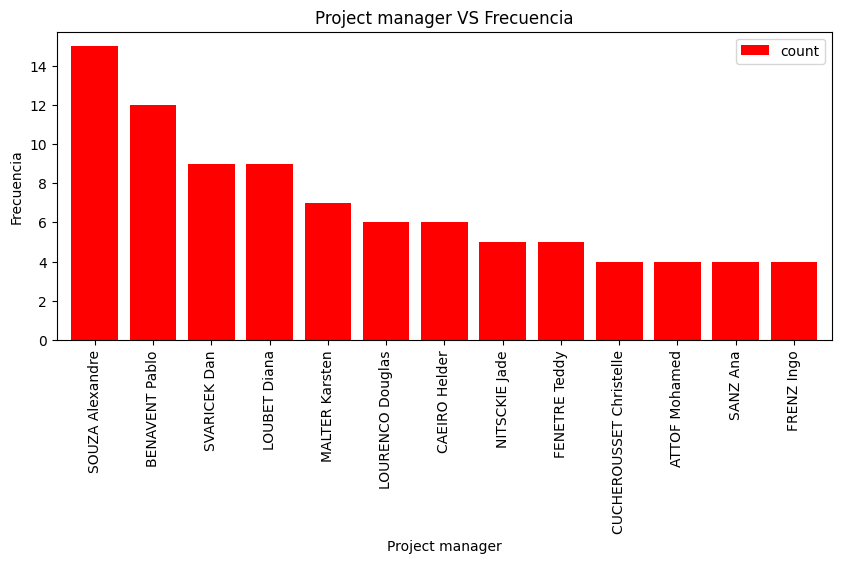

In [31]:
Filtro3_index.plot(kind='bar', width=0.8, figsize=(10,4), color="red")
plt.title('Project manager VS Frecuencia')
plt.xlabel('Project manager')
plt.ylabel('Frecuencia')

In [32]:
Tabla_freq2 = info_forvia_processed['Project organization'].value_counts().reset_index()
pd.options.display.max_rows = None
Tabla_freq2.head(15)

,Project organization,count
0,GIT/IT EMEA/MES & Digital Shopfloor projects,61
1,GIT/IT EMEA/Applications rollouts & Level 2 Su...,42
2,GIS/ITOP SAO./IT OP SAO shared/ITOP SAO FCS & ...,15
3,GIS/ITOP ASIA/IT OP Asia Shared/ITOP ASIA MES ...,14
4,GIT/IT NAO/MES Applications & DT/Mexico MES,13
5,GIT/Applications,10
6,GIT/Applications/Engineering / R&D Domain,10
7,GIT/IT NAO/NAO Applications/FCS,9
8,GIS/ITOP ASIA/IT OP Asia Shared/ITOP ASIA Infr...,8
9,GIT/IT NAO,8


In [33]:
Filtro3 = Tabla_freq2[Tabla_freq2['count']>4]
Filtro3

,Project organization,count
0,GIT/IT EMEA/MES & Digital Shopfloor projects,61
1,GIT/IT EMEA/Applications rollouts & Level 2 Su...,42
2,GIS/ITOP SAO./IT OP SAO shared/ITOP SAO FCS & ...,15
3,GIS/ITOP ASIA/IT OP Asia Shared/ITOP ASIA MES ...,14
4,GIT/IT NAO/MES Applications & DT/Mexico MES,13
5,GIT/Applications,10
6,GIT/Applications/Engineering / R&D Domain,10
7,GIT/IT NAO/NAO Applications/FCS,9
8,GIS/ITOP ASIA/IT OP Asia Shared/ITOP ASIA Infr...,8
9,GIT/IT NAO,8


In [34]:
Filtro3_index= Filtro3.set_index('Project organization')
Filtro3_index

,count
Project organization,
GIT/IT EMEA/MES & Digital Shopfloor projects,61
GIT/IT EMEA/Applications rollouts & Level 2 Support,42
GIS/ITOP SAO./IT OP SAO shared/ITOP SAO FCS & BPA.,15
GIS/ITOP ASIA/IT OP Asia Shared/ITOP ASIA MES & Digital Transformation,14
GIT/IT NAO/MES Applications & DT/Mexico MES,13
GIT/Applications,10
GIT/Applications/Engineering / R&D Domain,10
GIT/IT NAO/NAO Applications/FCS,9
GIS/ITOP ASIA/IT OP Asia Shared/ITOP ASIA Infrastructure,8


Text(0, 0.5, 'Frecuencia')

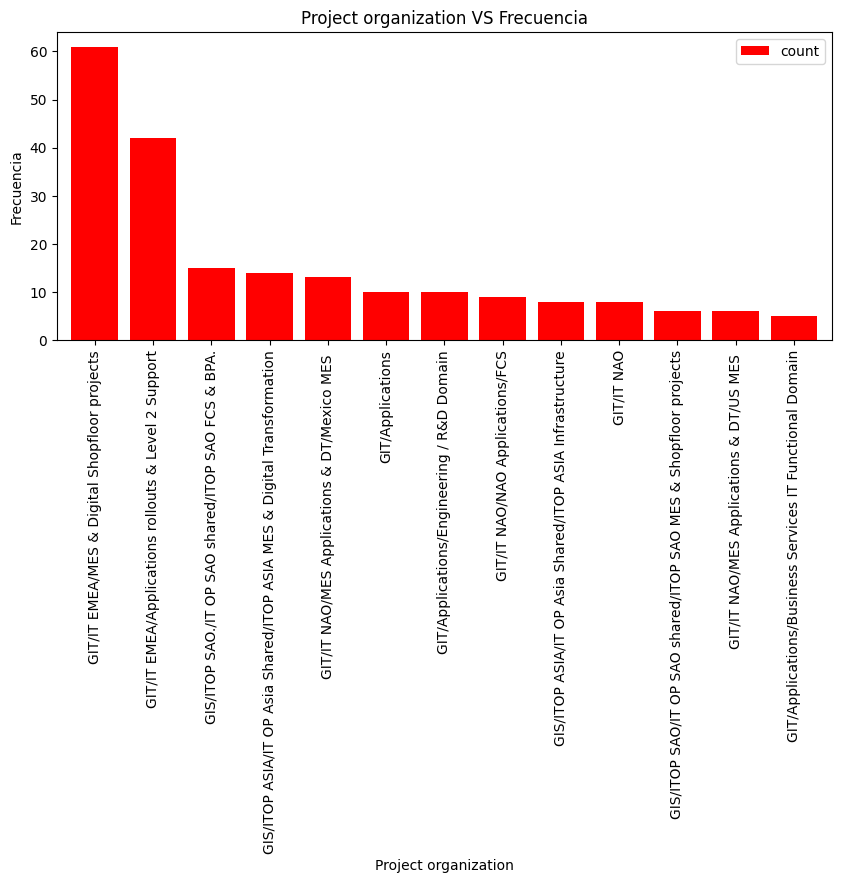

In [36]:
Filtro3_index.plot(kind='bar', width=0.8, figsize=(10,4), color="red")
plt.title('Project organization VS Frecuencia')
plt.xlabel('Project organization')
plt.ylabel('Frecuencia')

## Convertimos la columna a numarica para evitar errores

In [ ]:
info_forvia_processed["Percent complete"] = pd.to_numeric(info_forvia_processed["Percent complete"], errors="coerce")

## Calculamos el número de bins con la regla de sturges

In [ ]:
n = info_forvia_processed["Percent complete"].dropna().shape[0]
bins = int(1 + 3.322 * np.log10(n))

## Creamos las categorias

In [ ]:
info_forvia_processed["Percent_complete_cat"] = pd.cut(
    info_forvia_processed["Percent complete"],
    bins=bins,
    labels=[f"Grupo {i+1}" for i in range(bins)]
)

## Creamos una tabla de frecuencias

In [ ]:
freq_table = info_forvia_processed["Percent_complete_cat"].value_counts().sort_index()
display(freq_table.to_frame())

,count
Percent_complete_cat,
Grupo 1,78
Grupo 2,37
Grupo 3,30
Grupo 4,16
Grupo 5,13
Grupo 6,11
Grupo 7,14
Grupo 8,47


## Graficamos con el metodo de barras

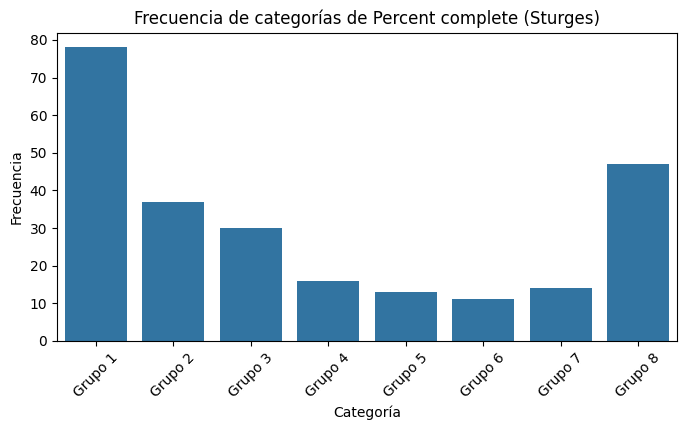

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(x="Percent_complete_cat", data=info_forvia_processed, order=freq_table.index)
plt.xticks(rotation=45)
plt.title("Frecuencia de categorías de Percent complete (Sturges)")
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.show()